In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
base = Path.cwd()
candidates = [base, base.parent, Path("/mnt/data")]
def locate(name):
    for p in candidates:
        q = p / name
        if q.exists():
            return q
    raise FileNotFoundError(name)
details = pd.read_csv(locate("order_details(3).csv"))
timestamps = pd.read_csv(locate("order_timestamp(3).csv"))
for c in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[c] = pd.to_datetime(timestamps[c], errors="coerce")
details["created_date"] = pd.to_datetime(details["created_date"], errors="coerce")
df = details.merge(timestamps, on="order_id", how="inner", validate="one_to_one")
df["BART_raw_min"] = (df["arrived_pickup_at"] - df["start_time_slot"]).dt.total_seconds()/60
df["BART_min"] = df["BART_raw_min"].clip(lower=0)
df["Acceptance_raw_min"] = (df["accept_time"] - df["start_time_slot"]).dt.total_seconds()/60
df["Acceptance_min"] = df["Acceptance_raw_min"].clip(lower=0)
df["Arrival_raw_min"] = (df["arrived_pickup_at"] - df["accept_time"]).dt.total_seconds()/60
df["Arrival_min"] = df["Arrival_raw_min"].clip(lower=0)
df["BART15"] = np.where(df["BART_min"].notna(), (df["BART_min"] <= 15).astype(int), np.nan)
df["hour"] = df["start_time_slot"].dt.hour
df["weekday"] = df["start_time_slot"].dt.day_name()
df["month"] = df["start_time_slot"].dt.month_name()
df["month_num"] = df["start_time_slot"].dt.month
df["date"] = df["start_time_slot"].dt.date
df["hour_bucket"] = df["start_time_slot"].dt.floor("h")
df["distance_km"] = df["total_distance"]/1000
df["fare_m"] = df["order_fare"]/1_000_000
df["fare_per_km"] = np.where(df["distance_km"]>0, df["order_fare"]/df["distance_km"], np.nan)
df["delayed_flag"] = np.where(df["order_offer_badge"].notna(), (df["order_offer_badge"].astype(str).str.lower()=="delayed").astype(int), np.nan)
df["district_str"] = df["district"].astype("Int64").astype(str)
df["city_district"] = df["order_city"].astype(str)+"-"+df["district_str"]
main = df[(df["start_time_slot"] >= pd.Timestamp("2025-08-01")) & (df["start_time_slot"] < pd.Timestamp("2025-11-01")) & df["BART_min"].notna()].copy()
seq = main[(main["start_time_slot"] <= main["accept_time"]) & (main["accept_time"] <= main["arrived_pickup_at"])].copy()
fig_dir = Path("assets/figures")
table_dir = Path("assets/tables")
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir/name, dpi=220, bbox_inches="tight")
    plt.show()
def save_table(data, name, decimals=2):
    x = data.copy()
    for c in x.select_dtypes(include=["float", "float64", "float32"]).columns:
        x[c] = x[c].round(decimals)
    display(x)


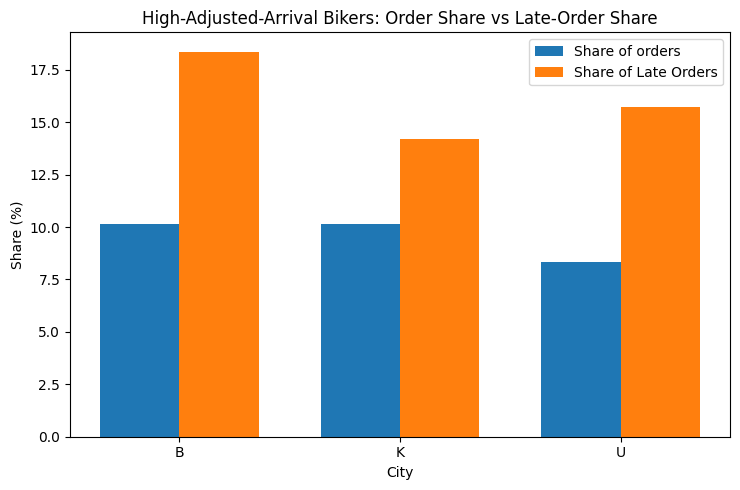

In [2]:
seq2=seq.copy()
base=seq2.groupby(["city_district","hour"])["Arrival_min"].median().rename("Arrival_base")
seq2=seq2.join(base,on=["city_district","hour"])
seq2["Adjusted_Arrival"]=seq2["Arrival_min"]-seq2["Arrival_base"]
biker=seq2.groupby(["order_city","biker"]).agg(Orders=("order_id","size"),Late_Orders=("BART15",lambda s:(s==0).sum()),Adjusted_Arrival=("Adjusted_Arrival","mean"),BART15=("BART15","mean")).reset_index()
biker=biker[biker["Orders"]>=30]
rows=[]
for city_name,g in biker.groupby("order_city"):
    cutoff=g["Adjusted_Arrival"].quantile(.90)
    high=g[g["Adjusted_Arrival"]>=cutoff]
    all_orders=g["Orders"].sum(); all_late=g["Late_Orders"].sum()
    rows.append({"City":city_name,"Share of Orders":high["Orders"].sum()/all_orders*100,"Share of Late Orders":high["Late_Orders"].sum()/all_late*100})
share=pd.DataFrame(rows)
x=np.arange(len(share)); w=.36
fig, ax=plt.subplots(figsize=(7.5,5))
ax.bar(x-w/2,share["Share of Orders"],w,label="Share of orders")
ax.bar(x+w/2,share["Share of Late Orders"],w,label="Share of Late Orders")
ax.set_xticks(x,labels=share["City"])
ax.set_title("High-Adjusted-Arrival Bikers: Order Share vs Late-Order Share")
ax.set_xlabel("City")
ax.set_ylabel("Share (%)")
ax.legend()
savefig("F28_High_Arrival_Biker_Order_vs_Late_Share.png")


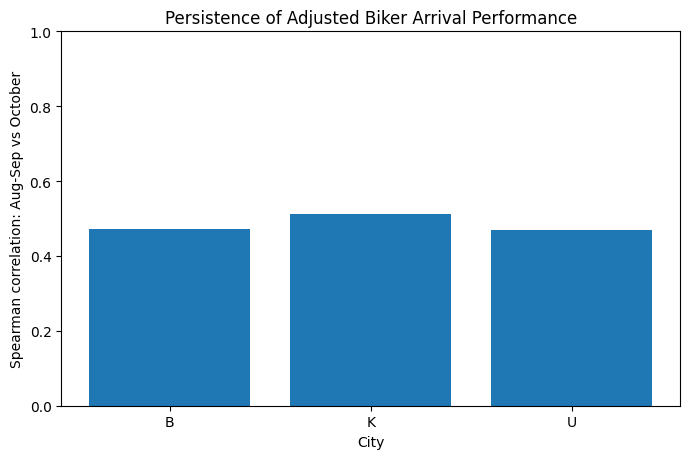

In [3]:
seq2["period"] = np.where(seq2["month_num"]<=9,"Aug-Sep","Oct")
piv=seq2.groupby(["order_city","biker","period"])["Adjusted_Arrival"].mean().unstack("period").dropna()
rows=[]
for city_name,g in piv.groupby(level=0):
    rows.append({"City":city_name,"Spearman persistence":g["Aug-Sep"].corr(g["Oct"],method="spearman")})
persist=pd.DataFrame(rows)
fig, ax=plt.subplots(figsize=(7,4.7))
ax.bar(persist["City"],persist["Spearman persistence"])
ax.set_ylim(0,1)
ax.set_title("Persistence of Adjusted Biker Arrival Performance")
ax.set_xlabel("City")
ax.set_ylabel("Spearman correlation: Aug-Sep vs October")
savefig("F29_Biker_Arrival_Persistence_by_City.png")


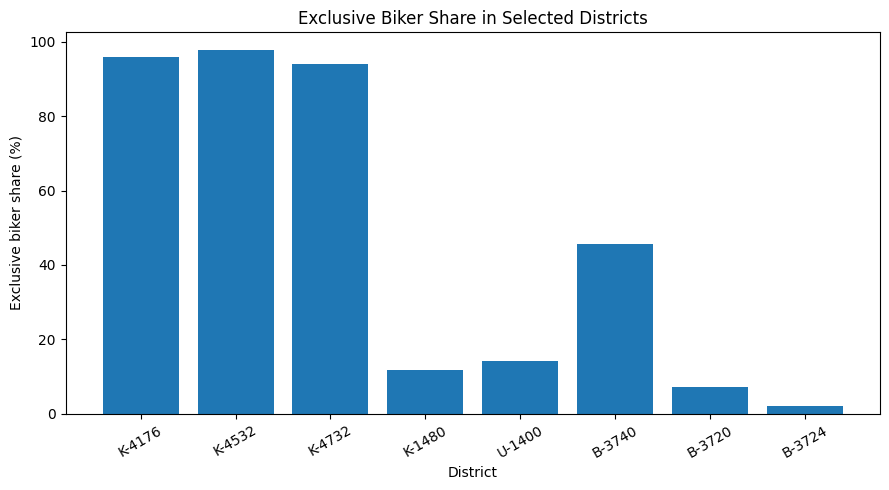

In [4]:
biker_district_count=main.dropna(subset=["biker","district"]).groupby("biker")["district"].nunique()
pairs=main.dropna(subset=["biker","district"])[["order_city","district","biker"]].drop_duplicates()
pairs["Exclusive"]=(pairs["biker"].map(biker_district_count)==1).astype(int)
structure=pairs.groupby(["order_city","district"]).agg(Exclusive_biker_share=("Exclusive","mean")).reset_index()
structure["Area"]=structure["order_city"]+"-"+structure["district"].astype(int).astype(str)
areas=["K-4176","K-4532","K-4732","K-1480","U-1400","B-3740","B-3720","B-3724"]
exc=structure[structure["Area"].isin(areas)].copy()
exc["Exclusive biker share (%)"]=exc["Exclusive_biker_share"]*100
exc=exc.set_index("Area").reindex(areas).reset_index()
fig, ax=plt.subplots(figsize=(9,5))
ax.bar(exc["Area"],exc["Exclusive biker share (%)"])
ax.set_title("Exclusive Biker Share in Selected Districts")
ax.set_xlabel("District")
ax.set_ylabel("Exclusive biker share (%)")
ax.tick_params(axis="x",rotation=30)
savefig("F30_Exclusive_Biker_Share_Selected_Districts.png")


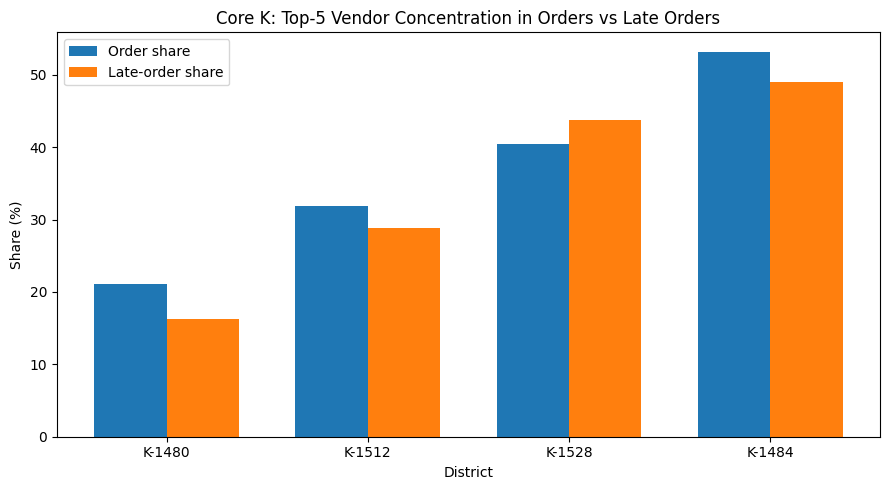

In [5]:
rows=[]
for area in ["K-1480","K-1512","K-1528","K-1484"]:
    g=main[main["city_district"]==area]
    vt=g.groupby("vendor").agg(Orders=("order_id","size"),Late=("BART15",lambda s:(s==0).sum())).sort_values("Orders",ascending=False)
    top=vt.head(5)
    rows.append({"Area":area,"Top 5 vendor share of orders (%)":top["Orders"].sum()/vt["Orders"].sum()*100,"Top 5 vendor share of Late Orders (%)":top["Late"].sum()/vt["Late"].sum()*100})
vend=pd.DataFrame(rows)
x=np.arange(len(vend));w=.36
fig, ax=plt.subplots(figsize=(9,5))
ax.bar(x-w/2,vend["Top 5 vendor share of orders (%)"],w,label="Order share")
ax.bar(x+w/2,vend["Top 5 vendor share of Late Orders (%)"],w,label="Late-order share")
ax.set_xticks(x,labels=vend["Area"])
ax.set_title("Core K: Top-5 Vendor Concentration in Orders vs Late Orders")
ax.set_xlabel("District")
ax.set_ylabel("Share (%)")
ax.legend()
savefig("F31_CoreK_Vendor_Concentration.png")


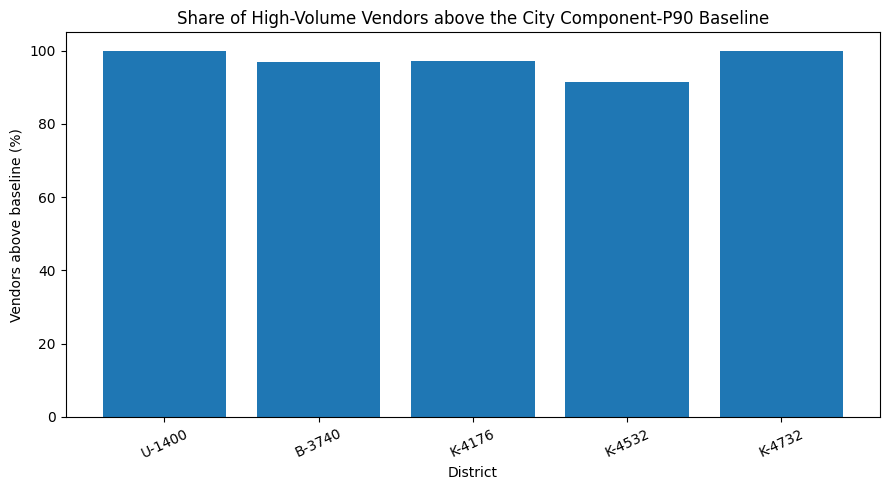

,Area,Metric,High-volume vendors,Share above city baseline (%)
0,U-1400,Acceptance P90,8,100.00
1,B-3740,Arrival P90,33,96.97
2,K-4176,Arrival P90,36,97.22
3,K-4532,Arrival P90,35,91.43
4,K-4732,Arrival P90,12,100.00


In [6]:
rows=[]
for area,metric in [("U-1400","Acceptance_min"),("B-3740","Arrival_min"),("K-4176","Arrival_min"),("K-4532","Arrival_min"),("K-4732","Arrival_min")]:
    g=seq[seq["city_district"]==area]
    city=area.split("-")[0]
    baseline=seq[seq["order_city"]==city][metric].quantile(.9)
    vt=g.groupby("vendor").agg(N=("order_id","size"),P90=(metric,lambda s:s.quantile(.9))).reset_index()
    vt=vt[vt["N"]>=30]
    rows.append({"Area":area,"Metric":"Acceptance P90" if metric=="Acceptance_min" else "Arrival P90","High-volume vendors":len(vt),"Share above city baseline (%)":(vt["P90"]>baseline).mean()*100 if len(vt) else np.nan})
vendor_diag=pd.DataFrame(rows)
fig, ax=plt.subplots(figsize=(9,5))
ax.bar(vendor_diag["Area"],vendor_diag["Share above city baseline (%)"])
ax.set_ylim(0,105)
ax.set_title("Share of High-Volume Vendors above the City Component-P90 Baseline")
ax.set_xlabel("District")
ax.set_ylabel("Vendors above baseline (%)")
ax.tick_params(axis="x",rotation=25)
savefig("F32_Vendor_Above_City_Baseline.png")
save_table(vendor_diag,"T09_Vendor_Breadth_Diagnostics.png")


In [7]:
rca=pd.DataFrame([
    ["K-1480","Acceptance","High-load deterioration","8,018 late orders; -3.40 pp Context Gap","Supply / assignment capacity"],
    ["K-1512","Acceptance","Persistent local bottleneck","3,367 late orders; -5.30 pp Context Gap","Assignment / offer process"],
    ["K-1528","Acceptance","Persistent local bottleneck","2,392 late orders; -6.82 pp Context Gap","Assignment / offer process"],
    ["U-1400","Acceptance","Broad local problem","1,256 late orders; -11.17 pp Context Gap","Offer / positioning / attractiveness"],
    ["B-3740","Arrival","Broad local problem","674 late orders; -6.15 pp Context Gap","Positioning / mobility"],
    ["K-4176/4532/4732","Arrival","Distinct process, not main K root cause","Highly isolated biker pools","Positioning / network structure"]
],columns=["Area","Dominant stage","Observed pattern","Evidence","Operational hypothesis"])
save_table(rca,"T10_RCA_Area_Summary.png")


,Area,Dominant stage,Observed pattern,Evidence,Operational hypothesis
0,K-1480,Acceptance,High-load deterioration,"8,018 late orders; -3.40 pp Context Gap",Supply / assignment capacity
1,K-1512,Acceptance,Persistent local bottleneck,"3,367 late orders; -5.30 pp Context Gap",Assignment / offer process
2,K-1528,Acceptance,Persistent local bottleneck,"2,392 late orders; -6.82 pp Context Gap",Assignment / offer process
3,U-1400,Acceptance,Broad local problem,"1,256 late orders; -11.17 pp Context Gap",Offer / positioning / attractiveness
4,B-3740,Arrival,Broad local problem,674 late orders; -6.15 pp Context Gap,Positioning / mobility
5,K-4176/4532/4732,Arrival,"Distinct process, not main K root cause",Highly isolated biker pools,Positioning / network structure
